## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import logging

import matplotlib.pyplot as plt
import numpy as np

import msml610_utils as ut

ut.config_notebook()

# Initialize logger.
logging.basicConfig(level=logging.INFO)
_LOG = logging.getLogger(__name__)

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
vim support installed: restart the notebook, if needed


Python 3.12.3
Linux f9ed2311dd60 6.12.67-linuxkit #1 SMP Sun Jan 25 02:26:28 UTC 2026 aarch64 aarch64 aarch64 GNU/Linux


In [2]:
import L09_05_01_discrete_bayes_dog_utils as ut

In [3]:
!sudo /bin/bash -c "(source /venv/bin/activate; pip install --quiet filterpy)"

# Cell 1: Tracking a Dog

## Cell 1.1: Problem Definition

- There is a dog with a sensor, that wanders around the offices and halls
- There are 10 positions in the hallway, numbered 0 to 9
    - The hallway is circular: there is position 0 after position 9
- The sensor reports if the dog is in front of a door and its movement
  - The sensor can have noise
- Can we find out where the dog is from consecutive measurements?

## Cell 1.2: Dog with Door Sensor

### A Simple Example with Perfect Sensors

In [4]:
# At the beginning, we don't know where the dog is.
# The prior is: "all the positions are equiprobable."
belief = np.array([1 / 10] * 10)
print(belief)

[0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]


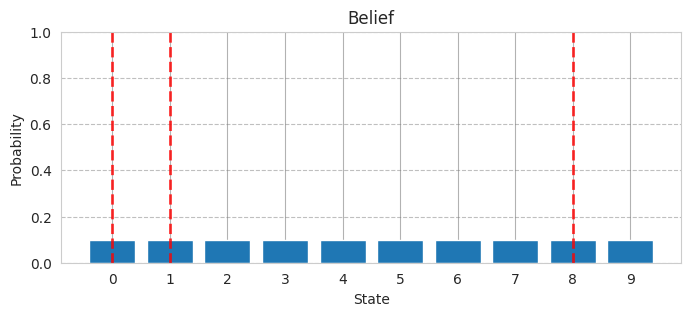

In [5]:
hallway = ut.get_hallway1()
ut.plot_belief(belief, hallway=hallway)

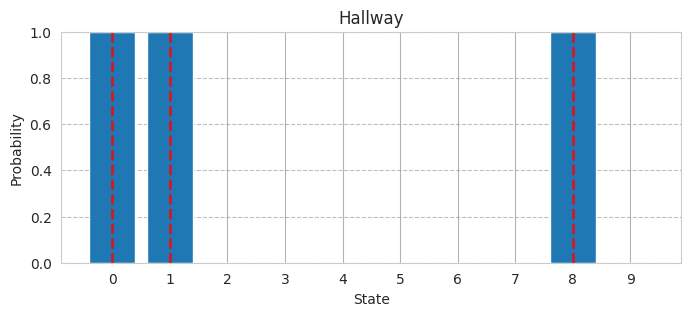

In [6]:
# The map of the office is the following.
hallway = ut.get_hallway1()
ut.plot_belief(hallway, hallway=hallway, title="Hallway")

- Let's assume that the sensor always returns the correct answer.
- The first reading from the sensor is "door"
- The dog is in front of a door, but we don't know which one
- We can update our belief state

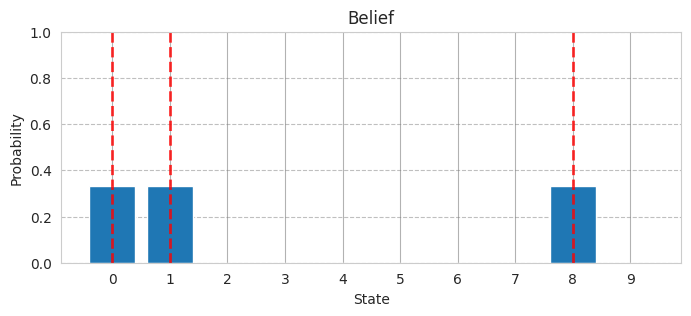

In [7]:
belief = np.array([1 / 3, 1 / 3, 0, 0, 0, 0, 0, 0, 1 / 3, 0])
ut.plot_belief(belief, hallway=hallway)

- The next readings are "door", "move right", "door"
- The only location possible is position #1
- So the belief is the following

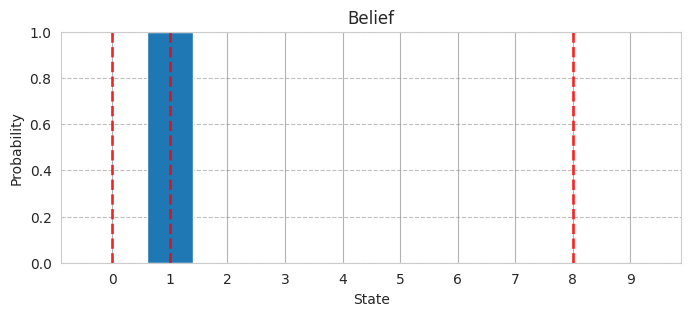

In [9]:
belief = np.array([0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
ut.plot_belief(belief, hallway=hallway)

### Noisy Door Sensor

- If the sensor is not reliable, it seemes impossible to determine where the dog is
    - "How can you conclude anything, if you are always unsure?"
- Let's assume that testing the sensor shows that the sensor is 3 times more likely to be right than wrong

belief: [0.3 0.3 0.1 0.1 0.1 0.1 0.1 0.1 0.3 0.1]
sum = 1.6000000000000003


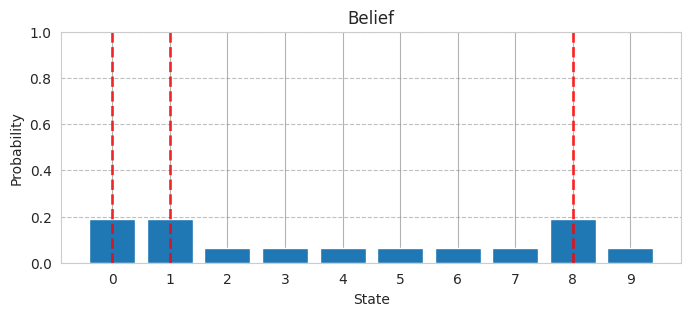

In [17]:
def update_belief(
    hall: np.ndarray, belief: ut.Pdf, z: int, correct_scale: float
) -> None:
    """
    Update belief in-place based on a measurement.

    Scales belief values by correct_scale for positions that match the
    measurement z.

    :param hall: Array representing the hallway map (0=wall, 1=door)
    :param belief: Array representing current belief distribution
    :param z: Measurement value (0 or 1)
    :param correct_scale: Scale factor for matching positions
    """
    for i, val in enumerate(hall):
        if val == z:
            belief[i] *= correct_scale


belief = np.array([0.1] * 10)
reading = 1  # 1 is 'door'
update_belief(hallway, belief, z=reading, correct_scale=3.0)
print("belief:", belief)
print("sum =", sum(belief))
belief /= sum(belief)
ut.plot_belief(belief, hallway=hallway)

- Now this is not a probability since the sum is 1.6 and not 1.0

sum = 1.0
probability of door = 0.1875
probability of wall = 0.06249999999999999


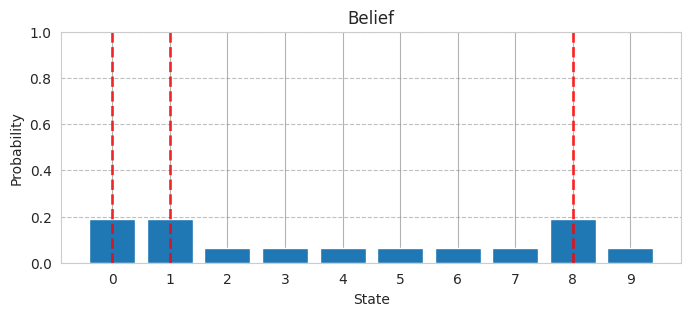

In [18]:
from filterpy.discrete_bayes import normalize


def scaled_update(
    hall: np.ndarray, belief: ut.Pdf, z: int, z_prob: float
) -> None:
    """
    Update belief using scaled likelihood based on measurement probability.

    Computes a scale factor from the measurement probability and applies it
    to positions matching the measurement, then normalizes.

    :param hall: Array representing the hallway map (0=wall, 1=door)
    :param belief: Array representing current belief distribution
    :param z: Measurement value (0 or 1)
    :param z_prob: Probability that the measurement is correct
    """
    scale = z_prob / (1.0 - z_prob)
    belief[hall == z] *= scale
    normalize(belief)


belief = np.array([0.1] * 10)
scaled_update(hallway, belief, z=1, z_prob=0.75)

print("sum =", sum(belief))
print("probability of door =", belief[0])
print("probability of wall =", belief[2])
ut.plot_belief(belief, hallway=hallway)

- Generalizing the update is always in the form of

  posterior = likelihood * prior / normalization

In [19]:
from filterpy.discrete_bayes import update


def lh_hallway(hall: np.ndarray, z: int, z_prob: float) -> ut.Pdf:
    """
    Compute likelihood that a measurement matches positions in the hallway.

    Creates a likelihood array where positions matching the measurement z
    are scaled according to the measurement probability.

    :param hall: Array representing the hallway map (0=wall, 1=door)
    :param z: Measurement value (0 or 1)
    :param z_prob: Probability that the measurement is correct
    :return: Likelihood array for all positions
    """
    try:
        scale = z_prob / (1.0 - z_prob)
    except ZeroDivisionError:
        scale = 1e8
    likelihood = np.ones(len(hall))
    likelihood[hall == z] *= scale
    return likelihood


belief = np.array([0.1] * 10)
likelihood = lh_hallway(hallway, z=1, z_prob=0.75)
# def update(likelihood, prior):
#    return normalize(likelihood * prior)
update(likelihood, belief)

array([0.1875, 0.1875, 0.0625, 0.0625, 0.0625, 0.0625, 0.0625, 0.0625,
       0.1875, 0.0625])

## Cell 1.3: Dog with Movement Sensor

### Incorporating movement

- Assume that the movement sensor is perfect
    - If the dog has moved to the right, we need to shift the belief to the right

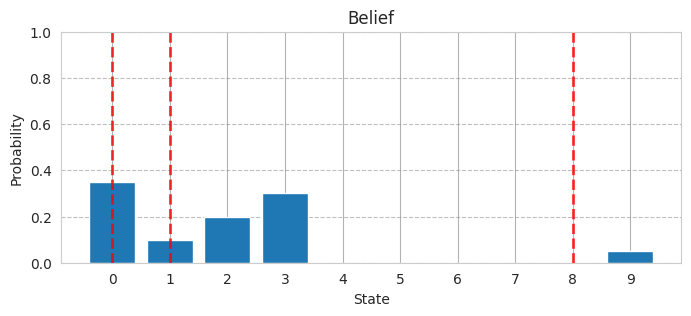

In [20]:
def perfect_predict(belief: ut.Pdf, move: int) -> ut.Pdf:
    """
    Move the position by `move` spaces with perfect prediction.

    Shifts the belief distribution where positive is to the right, and
    negative is to the left. Uses circular indexing for wrap-around.

    :param belief: Array representing current belief distribution
    :param move: Number of positions to move (positive=right, negative=left)
    :return: Updated belief distribution after movement
    """
    n = len(belief)
    result = np.zeros(n)
    for i in range(n):
        result[i] = belief[(i - move) % n]
    return result


belief = np.array([0.35, 0.1, 0.2, 0.3, 0, 0, 0, 0, 0, 0.05])
ut.plot_belief(belief, hallway=hallway)

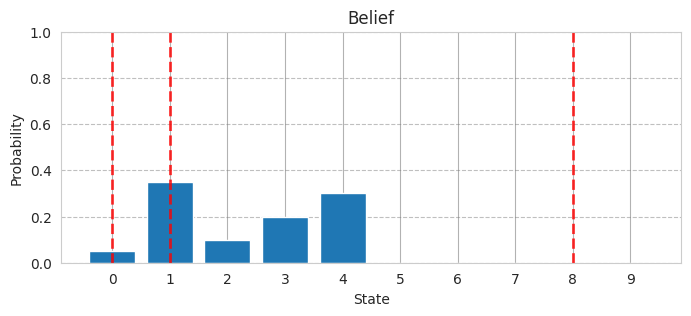

In [22]:
move = 1
new_belief = perfect_predict(belief, move)
ut.plot_belief(new_belief, hallway=hallway)

- Incorporating the movement of the dog means updating our belief of the PDF

### Terminology

- system: what we are trying to model
    - E.g., the dog
- state: configuration of the system
    - E.g., the position of the dog
- The filter produces an estimated state of the system
- process model: the dog moves one or more positions at each time st4ep

### Noisy Movement Sensor

- Assume that the sensor's movement measurement $z$ is:
  - 80% to be correct
  - 10% to overshoot by 1
  - 10% to undershoot by 1

- If movement measurement is 4, then the dog is:
  - 80% likely to have moved to the right for positions
  - 10% likely to have moved 3 or 5 spaces to the right

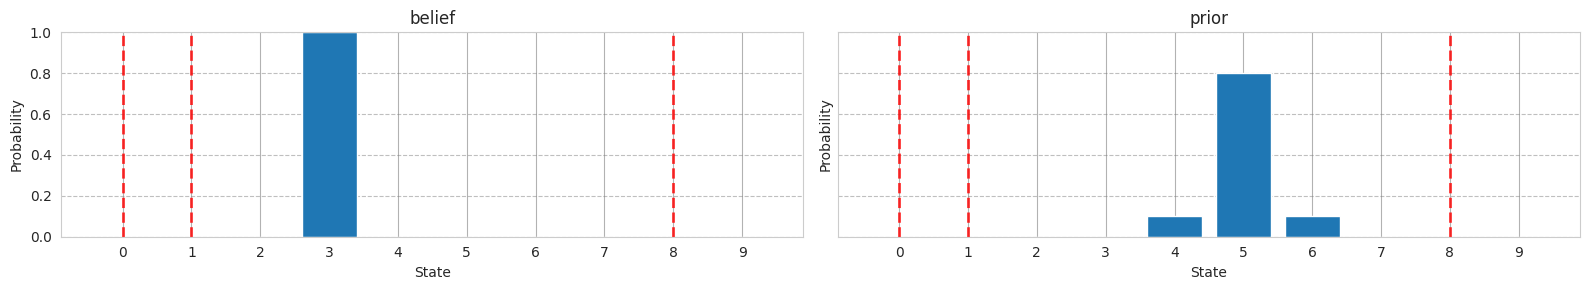

In [37]:
def predict_move(
    belief: ut.Pdf,
    move: int,
    p_under: float,
    p_correct: float,
    p_over: float,
) -> ut.Pdf:
    """
    Predict movement with uncertainty in the motion model.

    Models imperfect movement where the actual displacement can differ from
    the measured movement by ±1 position with specified probabilities.

    :param belief: Array representing current belief distribution
    :param move: Measured movement (number of positions)
    :param p_under: Probability of undershooting by 1 position
    :param p_correct: Probability of correct movement
    :param p_over: Probability of overshooting by 1 position
    :return: Prior belief distribution after movement prediction
    """
    n = len(belief)
    prior = np.zeros(n)
    for i in range(n):
        prior[i] = (
            belief[(i - move) % n] * p_correct
            + belief[(i - move - 1) % n] * p_over
            + belief[(i - move + 1) % n] * p_under
        )
    return prior


# Current belief.
belief = [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

# Belief after update with imperfect movement sensor.
move = 2
prior = predict_move(belief, move, 0.1, 0.8, 0.1)

ut.plot_beliefs(
    belief,
    prior,
    hallway=hallway,
    same_plot=False,
    title1="Belief",
    title2="Prior",
)

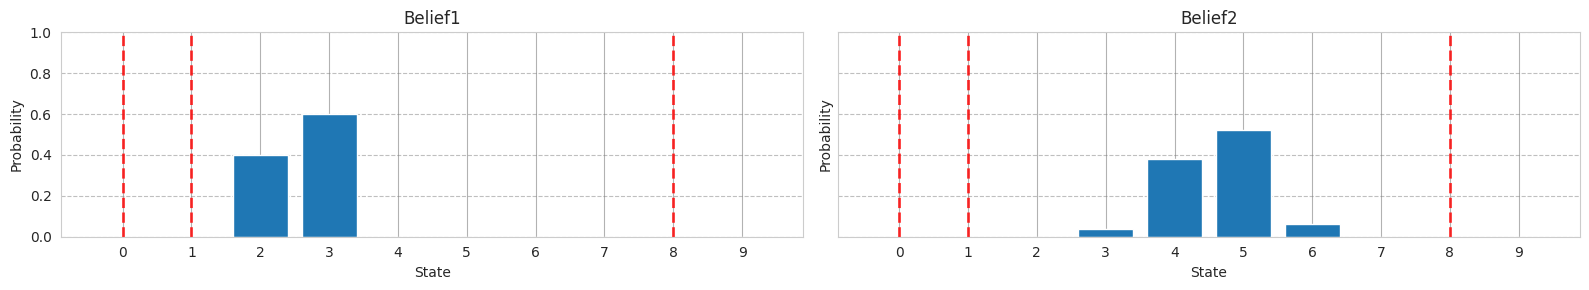

In [36]:
# Assume the belief is not correct.
belief = [0, 0, 0.4, 0.6, 0, 0, 0, 0, 0, 0]

move = 2
prior = predict_move(belief, move, 0.1, 0.8, 0.1)

ut.plot_beliefs(
    belief,
    prior,
    hallway=hallway,
    same_plot=False,
    title1="Belief",
    title2="Prior",
)

- After the update with the noisy sensor there is always some lost information
- For instance
    - We start with a strong belief on the dog being in position 0
    - We just get a reading of the dog movement and update our belief based on the prediction model
    - We don't have any door sensor update
    - The belief becomes flat (i.e., no information)

In [42]:
from ipywidgets import interact, IntSlider

belief = np.array([1.0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
predict_beliefs = []
predict_beliefs.append(belief)
print("Initial belief:", belief)

for i in range(100):
    move = 1
    belief = predict_move(belief, move, 0.1, 0.8, 0.1)
    predict_beliefs.append(belief)
print("Final Belief:", belief)


# Make an interactive plot.
def show_prior(step: int) -> None:
    """
    Display belief distribution at a specific step.

    Interactive callback function to visualize how belief evolves over time.

    :param step: Time step to display (1-indexed)
    """
    ut.plot_belief(predict_beliefs[step - 1], hallway=hallway)
    plt.title(f"Step {step}")
    plt.show()


interact(show_prior, step=IntSlider(value=1, max=len(predict_beliefs)));

Initial belief: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Final Belief: [0.10407069 0.10329322 0.10125784 0.09874205 0.09670682 0.09592945
 0.09670682 0.09874205 0.10125784 0.10329322]


interactive(children=(IntSlider(value=1, description='step', max=101), Output()), _dom_classes=('widget-intera…

- Generalizing the model prediction uncertainty requires a convolution which is conceptually implemented as below

In [43]:
def predict_move_convolution(pdf: ut.Pdf, offset: int, kernel: ut.Pdf) -> ut.Pdf:
    N = len(pdf)
    kN = len(kernel)
    width = int((kN - 1) / 2)

    prior = np.zeros(N)
    for i in range(N):
        for k in range(kN):
            index = (i + (width - k) - offset) % N
            prior[i] += pdf[index] * kernel[k]
    return prior

- This is a generalization of the previous formula so it returns the same result

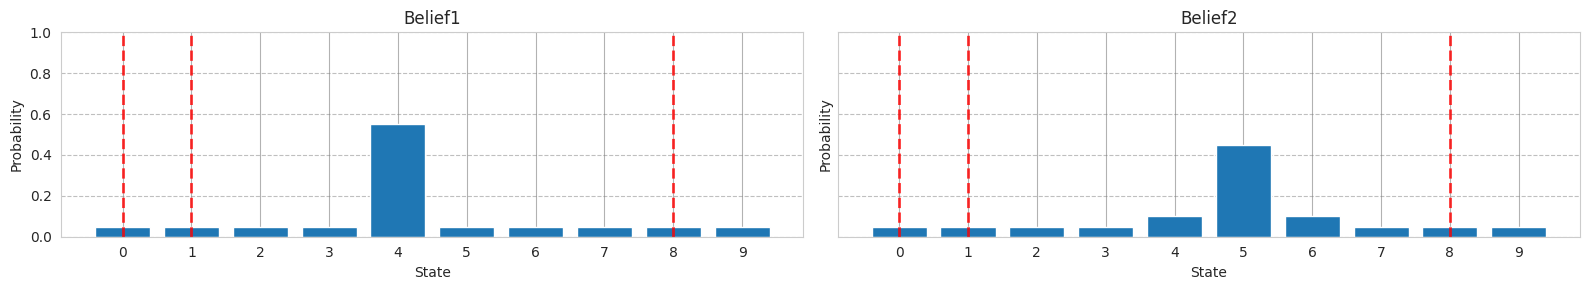

In [46]:
belief = [0.05, 0.05, 0.05, 0.05, 0.55, 0.05, 0.05, 0.05, 0.05, 0.05]

prior = predict_move_convolution(belief, offset=1, kernel=[0.1, 0.8, 0.1])

ut.plot_beliefs(belief, prior, hallway=hallway, same_plot=False)

- A more efficient implementation using numpy is here

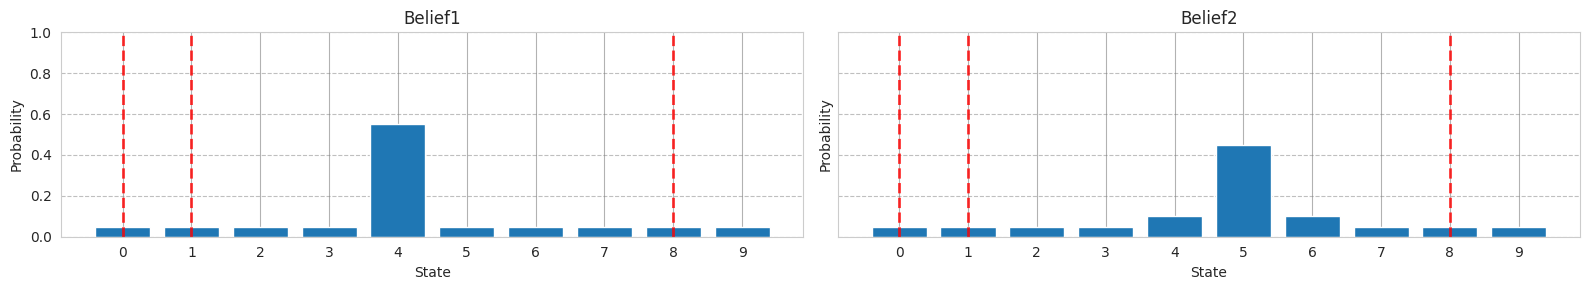

In [48]:
# Using filterpy.

from filterpy.discrete_bayes import predict

belief = [0.05, 0.05, 0.05, 0.05, 0.55, 0.05, 0.05, 0.05, 0.05, 0.05]
prior = predict(belief, offset=1, kernel=[0.1, 0.8, 0.1])
ut.plot_beliefs(belief, prior, hallway=hallway, same_plot=False)

- An example with a more complex and asymmetric model uncertainty is below
- You can see how the belief becomes more uncertain

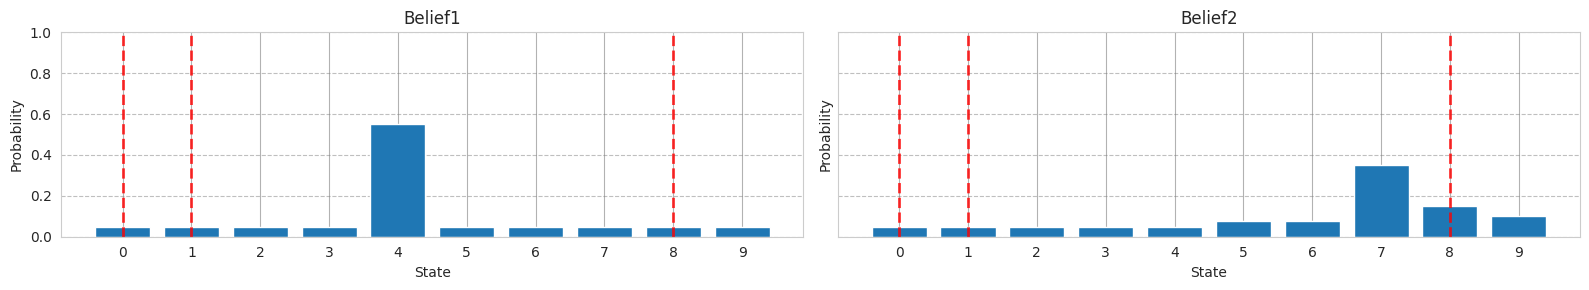

In [51]:
kernel = (0.05, 0.05, 0.6, 0.2, 0.1)
belief = [0.05, 0.05, 0.05, 0.05, 0.55, 0.05, 0.05, 0.05, 0.05, 0.05]
prior = predict(belief, offset=3, kernel=kernel)

ut.plot_beliefs(belief, prior, hallway=hallway, same_plot=False)

### Integrating Measurements and Updates

- Each model prediction loses information / knowledge (at best, there is no improvement)
- With each sensor update, we incorporate the measurement into the estimate, which improvoves knowledge
- The output of the update step is then fed into the next prediction

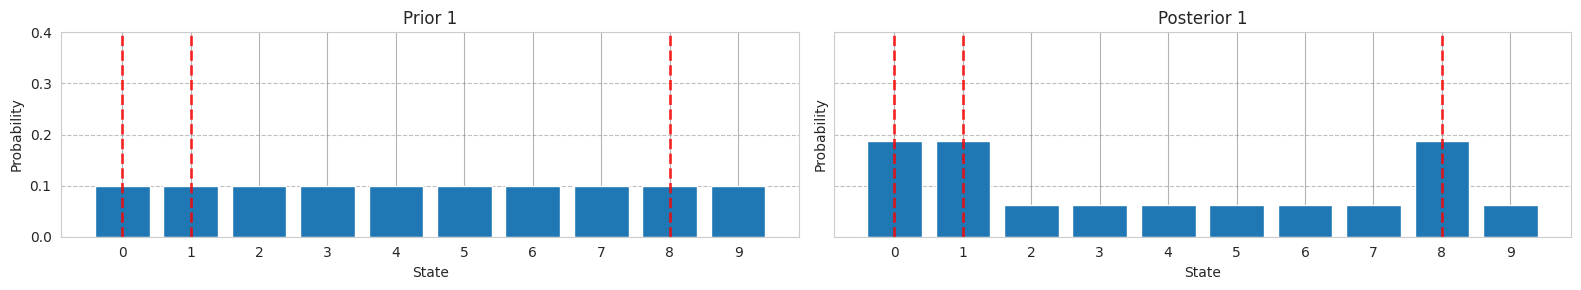

In [54]:
hallway = ut.get_hallway1()
# Sensor measurements are imperfect.
kernel = (0.1, 0.8, 0.1)

# We don't have any information. The dog could be anywhere.
prior1 = np.array([0.1] * 10)

# The sensor tells that the dog is in front of a door, but the sensor is imprecise.
sensor = 1
likelihood = ut.lh_hallway(hallway, z=sensor, z_prob=0.75)

posterior1 = update(likelihood, prior1)

y_lim = (0, 0.4)
ut.plot_beliefs(
    prior1,
    posterior1,
    title1="Prior 1",
    title2="Posterior 1",
    y_lim=y_lim,
    hallway=hallway,
    same_plot=False,
)

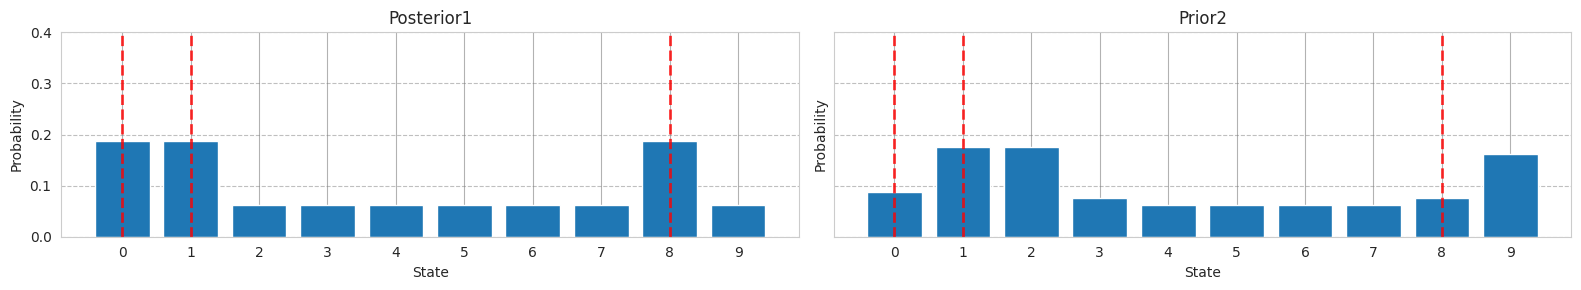

In [56]:
# The sensor says that the dog moved to the right.
move = 1
prior2 = predict(posterior1, move, kernel)
ut.plot_beliefs(
    posterior1,
    prior2,
    title1="Posterior1",
    title2="Prior2",
    y_lim=y_lim,
    hallway=hallway,
    same_plot=False,
)

# The probabilities move to the right and get smeared a bit.

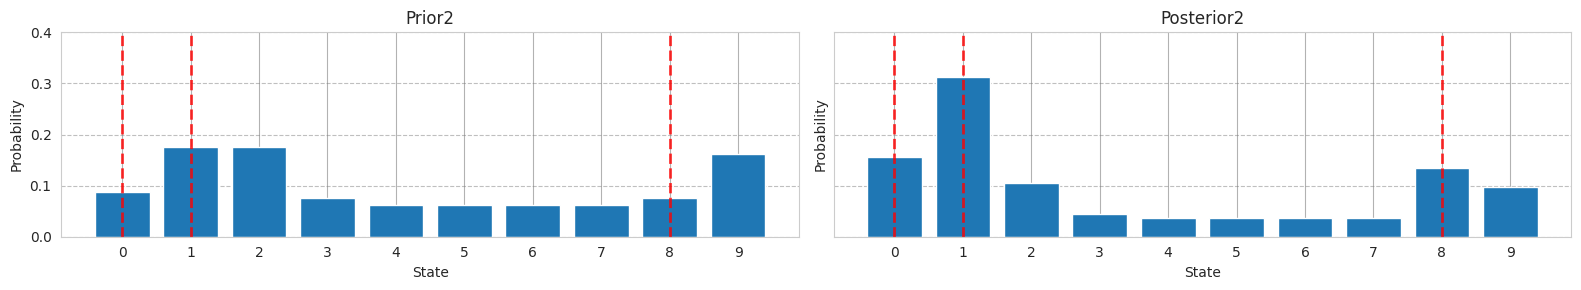

In [57]:
# The sensor reports another door.
likelihood = ut.lh_hallway(hallway, z=1, z_prob=0.75)
posterior2 = update(likelihood, prior2)

ut.plot_beliefs(
    prior2,
    posterior2,
    title1="Prior2",
    title2="Posterior2",
    y_lim=y_lim,
    hallway=hallway,
    same_plot=False,
)
# The belief is that the dog is in front of position 1.

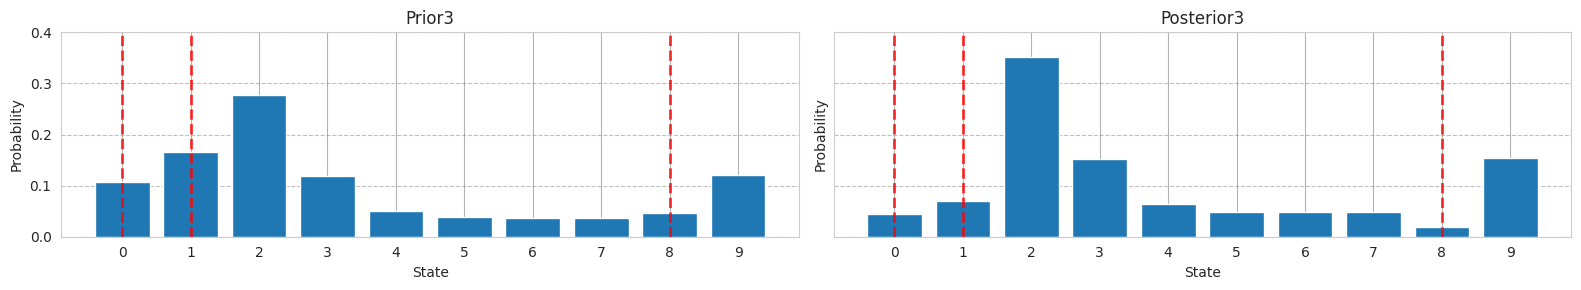

In [58]:
# Then the dog moves again.
move = 1
prior3 = predict(posterior2, move, kernel)
likelihood = ut.lh_hallway(hallway, z=0, z_prob=0.75)
posterior3 = update(likelihood, prior3)
ut.plot_beliefs(
    prior3,
    posterior3,
    title1="Prior3",
    title2="Posterior3",
    y_lim=y_lim,
    hallway=hallway,
    same_plot=False,
)

# Cell 2: A Bayes Dog Simulation

## Cell 2.1: Interactive Visualization

- The dog has a door sensor and a movement sensor and runs around the hallway
- The green line marks where the dog actually is at each step
- Two plots show the filter in action:
  - **Left plot**: Dog movement trajectory over time with current position highlighted (in green)
  - **Right plot**: Belief distribution (Prior or Posterior) with red lines marking door positions

The interactive visualization includes four controls:

1. **Movement**: Select the dog's movement pattern
   - Movement 1 (around office): Dog traverses all 10 positions sequentially for 50 steps
   - Movement 2 (between doors): Dog alternates between positions 0 and 1 for 50 steps
   - ...

2. **Initial Prior**: Choose the starting belief distribution
   - Flat (uniform): We don't know where the dog is, so we assume it can be anywhere
   - All in position 3: We believe the dog is at position 3
   - All in position 8: We believe the dog is at position 8

3. **z_prob**: Door sensor accuracy (0.0 to 1.0)
   - Probability that the door sensor measurement is correct
   - 1.0 = perfect sensor (always correct)
   - 0.75 = sensor is correct 75% of the time
   - Lower values add more noise to measurements

4. The movement sensor is imperfect but mostly ok, i.e., kernel = (0.1, 0.8, 0.1)

In [59]:
ut.cell2_1_interactive()

**movement1**

- With movement1, z_prob = 1
    - The prior shifts tracking the dog pretty well
    - When the dog is in front of a door, the estimate becomes more accurate
    - When the dog is in a stretch of no doors, the estimate is less certain

- When the initial prior is concentrated in the wrong position
    - The prior is wrong but, over time, it is corrected by data
 
- When the door sensor is less precise (i.e., the `z_prob` decreases), the estimates get worse

**movements2**
- The dog moves between two doors 0 and 1
- The sensor is very precise (since there are lots of doors and so lots of information coming in)

**movements3**
- Same phenomena

## Cell 2.2: Bad Sensor Data

- Let's consider the case of a symmetric office geometry and a dog running in circles
    ```
    [1, 1, 0, 1, 0, 1, 1, 0, 1, 0]
    ```
- We can intuit that the correct answer is the filter aligned with the dog but with uncertainty on which half of the hallway it is

- Then we can inject a completely wrong measure using a bad sensor
    ```
    [1, 1, 0, 1, 0, 1, 1, 1, 0, 0]
    ```
  - The first part of the simulation is the usual one
  - Around step 14-16 you can see that the filter is "surprised" by the bad measure
  - Then it recovers

In [61]:
ut.cell2_2_interactive()

- Although this example is very simple, it incorporates all the concept that a Kalman filter relies on